In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from PIL import Image
import cv2
from tqdm import tqdm


def _load_instruction(episode_dir: str) -> str :
    """Load instruction text from instruction.txt if it exists."""
    path = os.path.join(episode_dir, "instruction.txt")
    if os.path.exists(path):
        with open(path, "r") as f:
            return f.read().strip()
    return None


def _render_frame(
    background: np.ndarray,
    masks: np.ndarray,
    distances: np.ndarray,
    colormap: str,
    alpha: float,
    global_d_min: float,
    global_d_max: float,
    fig_w_px: int,
    fig_h_px: int,
    instruction: str ,
) -> np.ndarray:
    """Render one side-by-side frame and return it as a (H, W, 3) uint8 array."""
    H, W = background.shape[:2]
    finite_mask = np.isfinite(distances)

    # ── Build overlay ─────────────────────────────────────────────────────────
    overlay = np.zeros((H, W, 4), dtype=np.float32)
    cmap = plt.get_cmap(colormap)

    if masks.ndim == 3 and masks.shape[0] > 0:
        N = masks.shape[0]
        dist_norm = np.full(N, np.nan)
        if finite_mask.any():
            rng = global_d_max - global_d_min
            if rng > 0:
                dist_norm[finite_mask] = (distances[finite_mask] - global_d_min) / rng
            else:
                dist_norm[finite_mask] = 0.5

        for i in range(N):
            binary = masks[i].astype(bool)
            if not binary.any():
                continue
            if np.isnan(dist_norm[i]):
                colour = np.array([0.5, 0.5, 0.5, alpha], dtype=np.float32)
            else:
                rgba = cmap(dist_norm[i])
                colour = np.array([rgba[0], rgba[1], rgba[2], alpha], dtype=np.float32)
            overlay[binary] = colour

    bg_f = background.astype(np.float32) / 255.0
    out_rgb = bg_f * (1 - overlay[..., 3:4]) + overlay[..., :3] * overlay[..., 3:4]
    out_rgb = (np.clip(out_rgb, 0, 1) * 255).astype(np.uint8)
    alpha_ch = np.where(overlay[..., 3] > 0, 255, 200).astype(np.uint8)
    vis = np.dstack([out_rgb, alpha_ch])

    # ── Matplotlib figure → numpy array ──────────────────────────────────────
    dpi = 100

    # Reserve extra vertical space at bottom for instruction banner
    instruction_px = 48 if instruction else 0
    figsize_h = (fig_h_px + instruction_px) / dpi

    fig = plt.figure(figsize=(fig_w_px / dpi, figsize_h), facecolor="black")

    # GridSpec: top row = images, optional bottom row = instruction banner
    if instruction:
        gs = fig.add_gridspec(
            2, 2,
            height_ratios=[fig_h_px, instruction_px],
            hspace=0.0,
            wspace=0.05,
        )
        ax_left  = fig.add_subplot(gs[0, 0])
        ax_right = fig.add_subplot(gs[0, 1])
        ax_text  = fig.add_subplot(gs[1, :])
    else:
        gs = fig.add_gridspec(1, 2, wspace=0.05)
        ax_left  = fig.add_subplot(gs[0, 0])
        ax_right = fig.add_subplot(gs[0, 1])
        ax_text  = None

    # Left panel: raw RGB
    ax_left.imshow(background)
    ax_left.set_title("RGB", color="white", fontsize=10, pad=6)
    ax_left.axis("off")

    # Right panel: geodesic overlay
    ax_right.imshow(vis)
    ax_right.set_title("Geodesic Distances", color="white", fontsize=10, pad=6)
    ax_right.axis("off")

    # Colorbar
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=mcolors.Normalize(vmin=global_d_min, vmax=global_d_max),
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax_right, fraction=0.046, pad=0.04)
    cbar.set_label("Geodesic distance (m)", color="white", fontsize=8)
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

    has_missing = not finite_mask.all() if finite_mask.size > 0 else False
    if has_missing:
        ax_right.legend(
            handles=[Patch(facecolor="grey", label="No distance")],
            loc="lower left", fontsize=7, framealpha=0.5, labelcolor="white",
        )

    # ── Instruction banner ────────────────────────────────────────────────────
    if ax_text is not None:
        ax_text.set_facecolor("#111111")
        ax_text.axis("off")
        ax_text.text(
            0.5, 0.5,
            f"Task: {instruction}",
            color="#FFD700",           # gold – readable on dark background
            fontsize=10,
            fontweight="bold",
            ha="center",
            va="center",
            transform=ax_text.transAxes,
            wrap=True,
            clip_on=True,
        )
        # Thin separator line between panels and banner
        line = plt.Line2D(
            [0, 1], [1, 1],
            transform=ax_text.transAxes,
            color="#444444",
            linewidth=1,
        )
        ax_text.add_line(line)

    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    buf = buf.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)
    return buf


def episode_to_video(
    episode_dir: str,
    output_path: str,
    colormap: str = "plasma",
    alpha: float = 0.65,
    fps: int = 10,
    frame_prefix: str = "frame_",
) -> None:
    """
    Render all frames from an episode directory into a side-by-side video,
    with the instruction from instruction.txt shown as a banner at the bottom.

    Expected layout
    ---------------
    episode_dir/
        instruction.txt             # optional – one line task description
        frame_0000/
            rgb.png
            masks.npy               # (N, H, W) uint8
            geodesic_distances.npy  # (N,)      float32
        frame_0001/
            ...

    Parameters
    ----------
    episode_dir   : root directory containing per-frame sub-directories
    output_path   : path for the output .mp4 file
    colormap      : matplotlib colormap for distance colouring
    alpha         : overlay opacity
    fps           : frames per second in the output video
    frame_prefix  : common prefix of per-frame sub-directory names
    """
    # ── Discover & sort frame directories ────────────────────────────────────
    frame_dirs = sorted(
        [
            os.path.join(episode_dir, d)
            for d in os.listdir(episode_dir)
            if os.path.isdir(os.path.join(episode_dir, d))
            and d.startswith(frame_prefix)
        ]
    )
    if not frame_dirs:
        raise FileNotFoundError(
            f"No sub-directories starting with '{frame_prefix}' found in {episode_dir}"
        )

    print(f"Found {len(frame_dirs)} frames.")

    # ── Load instruction ──────────────────────────────────────────────────────
    instruction = _load_instruction(episode_dir)
    if instruction:
        print(f"Instruction: {instruction}")
    else:
        print("No instruction.txt found – banner will be omitted.")

    # ── Pass 1: global distance range for a consistent colorbar ──────────────
    print("Computing global distance range …")
    all_finite = []
    for fd in frame_dirs:
        dist_path = os.path.join(fd, "geodesic_distances.npy")
        if os.path.exists(dist_path):
            d = np.load(dist_path)
            finite = d[np.isfinite(d)]
            if finite.size:
                all_finite.append(finite)

    if all_finite:
        all_finite = np.concatenate(all_finite)
        global_d_min, global_d_max = float(all_finite.min()), float(all_finite.max())
    else:
        global_d_min, global_d_max = 0.0, 1.0

    print(f"Distance range: [{global_d_min:.3f}, {global_d_max:.3f}] m")

    # ── Determine output frame size from the first valid frame ────────────────
    first_rgb = np.array(Image.open(os.path.join(frame_dirs[0], "rgb.png")).convert("RGB"))
    H, W = first_rgb.shape[:2]
    fig_w_px = W * 2 + 120
    fig_h_px = H + 60

    # ── Pass 2: render frames & write video ───────────────────────────────────
    writer = None

    for fd in tqdm(frame_dirs, desc="Rendering frames"):
        rgb_path   = os.path.join(fd, "rgb.png")
        masks_path = os.path.join(fd, "masks.npy")
        dist_path  = os.path.join(fd, "geodesic_distances.npy")

        background = (
            np.array(Image.open(rgb_path).convert("RGB"))
            if os.path.exists(rgb_path)
            else np.full((H, W, 3), 30, dtype=np.uint8)
        )
        masks = (
            np.load(masks_path)
            if os.path.exists(masks_path)
            else np.zeros((0, H, W), dtype=np.uint8)
        )
        distances = (
            np.load(dist_path)
            if os.path.exists(dist_path)
            else np.zeros(0, dtype=np.float32)
        )

        frame_rgb = _render_frame(
            background, masks, distances,
            colormap, alpha,
            global_d_min, global_d_max,
            fig_w_px, fig_h_px,
            instruction=instruction,
        )

        if writer is None:
            out_h, out_w = frame_rgb.shape[:2]
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
            writer = cv2.VideoWriter(output_path, fourcc, fps, (out_w, out_h))

        writer.write(cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR))

    if writer:
        writer.release()
        print(f"Video saved → {output_path}")
    else:
        print("No frames were rendered.")

In [17]:
vis = episode_to_video(
    episode_dir="/media/opervu-user/Data2/ws/data_langgeonet/episode_18119/",
    output_path="./episode_18119.mp4",
    colormap="plasma",   # try "viridis", "turbo", "inferno"
    alpha=0.7,
)

Found 73 frames.
Instruction: Now you are facing to the two couches and a photo frame. Turn slightly right and move forward by passing the two couches on your left, on the left you can see wooden rack move towards it and move forward by passing the railing on your right, on your left there is a open door, enter into the room and move towards the fire place and turn right stop in front of the chair.
Computing global distance range …
Distance range: [0.000, 1.000] m


Rendering frames:   0%|          | 0/73 [00:00<?, ?it/s]/tmp/ipykernel_1530861/70186788.py:147: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
Rendering frames:   3%|▎         | 2/73 [00:00<00:11,  6.38it/s]

Rendering frames: 100%|██████████| 73/73 [00:10<00:00,  6.72it/s]

Video saved → ./episode_18119.mp4


---
---

## GT topometric map

In [3]:
import os
import cv2
import pickle
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pycocotools import mask as mask_utils

def show_node(episode_dir, node_idx):
    """
    Visualize a single graph node by overlaying its segmentation mask
    on the corresponding RGB frame.

    Parameters
    ----------
    episode_dir : str
        Path to episode directory e.g. /media/.../episode_21909/
    node_idx : int
        Node index in the graph
    """
    # ── Load graph ────────────────────────────────────────────────────────────
    graph_path = os.path.join(episode_dir, "nodes_graphObject_4_gt_topometric.pickle")
    if not os.path.exists(graph_path):
        # fallback: find any .pickle file
        picks = [f for f in os.listdir(episode_dir) if f.endswith(".pickle")]
        if not picks:
            raise FileNotFoundError(f"No pickle graph found in {episode_dir}")
        graph_path = os.path.join(episode_dir, picks[0])

    G = pickle.load(open(graph_path, "rb"))
    all_paths = G.graph['all_paths_lengths']
    print(all_paths.shape)
    if node_idx not in G.nodes:
        raise ValueError(f"Node {node_idx} not in graph. Valid range: 0 – {G.number_of_nodes()-1}")

    node = G.nodes[node_idx]

    # # ── Get frame index and load RGB ─────────────────────────────────────────
    frame_idx, region_idx = node['map']
    img_path = os.path.join(episode_dir, f"frame_{frame_idx:03d}", "rgb.png")
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"RGB image not found: {img_path}")

    rgb = cv2.imread(img_path)[:, :, ::-1]  # BGR → RGB
    H, W = rgb.shape[:2]

    # # ── Decode RLE segmentation mask ─────────────────────────────────────────
    rle = node['segmentation']
    compressed_rle = mask_utils.frPyObjects(rle, rle['size'][0], rle['size'][1])

    # pycocotools expects {'size': [H, W], 'counts': ...}
    if 'size' not in rle:
        rle = {'size': [H, W], 'counts': rle['counts']}
    mask = mask_utils.decode(compressed_rle).astype(bool)  # (H, W) bool

    # # ── Build overlay ─────────────────────────────────────────────────────────
    overlay = rgb.copy()
    color = np.array([0, 255, 100], dtype=np.uint8)  # green highlight
    overlay[mask] = (0.45 * overlay[mask] + 0.55 * color).astype(np.uint8)

    # draw mask contour
    contours, _ = cv2.findContours(
        mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    cv2.drawContours(overlay, contours, -1, (0, 220, 80), 2)

    # ── Extract metadata ──────────────────────────────────────────────────────
    inst_dict   = node.get('instance_dict', {})
    cat_name    = node.get('category_name',  inst_dict.get('category_name', 'unknown'))
    instance_id = node.get('instance_id',    inst_dict.get('id', '?'))
    obb_center  = inst_dict.get('obb_center', None)
    pos         = node.get('agent_position', None)

    # ── Neighbours ───────────────────────────────────────────────────────────
    neighbours = list(G.neighbors(node_idx))

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Node {node_idx}  |  Frame {frame_idx}, Region {region_idx}", fontsize=13)

    # left: raw frame with all nodes in this frame highlighted dimly
    axes[0].imshow(rgb)
    axes[0].set_title(f"Raw Frame {frame_idx}")
    axes[0].axis('off')

    # right: overlay
    axes[1].imshow(overlay)
    axes[1].set_title(f"Node mask  —  '{cat_name}'  (instance {instance_id})")
    axes[1].axis('off')

    # centroid dot
    if mask.any():
        ys, xs = np.where(mask)
        cy, cx = ys.mean(), xs.mean()
        axes[1].plot(cx, cy, 'r+', markersize=12, markeredgewidth=2)

    # info text box
    # lines = [
    #     f"node_idx      : {node_idx}",
    #     f"frame_idx     : {frame_idx}",
    #     f"region_idx    : {region_idx}",
    #     f"category      : {cat_name}",
    #     f"instance_id   : {instance_id}",
    #     f"obb_center    : {np.round(obb_center, 3) if obb_center is not None else 'N/A'}",
    #     f"agent_pos     : {np.round(pos, 3) if pos is not None else 'N/A'}",
    #     f"num_neighbours: {len(neighbours)}",
    #     f"neighbour_ids : {neighbours[:10]}{'...' if len(neighbours)>10 else ''}",
    # ]
    # info_txt = "\n".join(lines)
    # fig.text(0.01, 0.01, info_txt, fontsize=8,
    #          verticalalignment='bottom',
    #          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    # plt.savefig(f"node_{node_idx}_frame{frame_idx}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → node_{node_idx}_frame{frame_idx}.png")
    return fig



(1019, 1019)


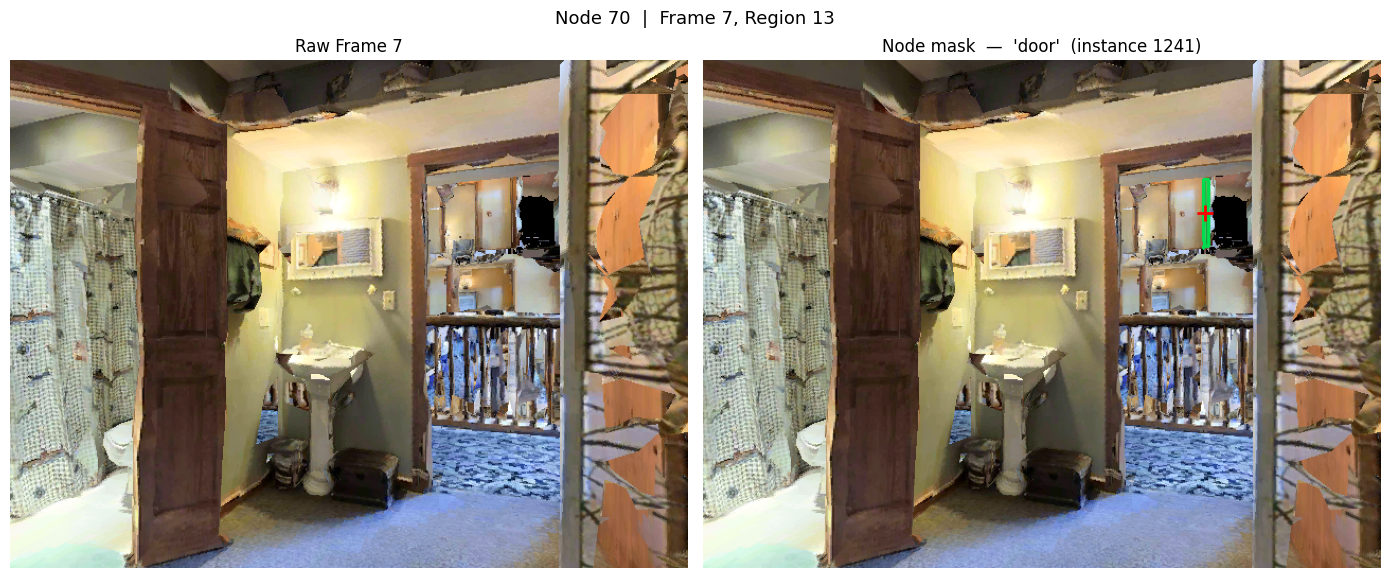

Saved → node_70_frame7.png


In [53]:
output= show_node(
    episode_dir="/media/opervu-user/Data2/ws/data_langgeonet_e3d/episode_21909/",
    node_idx=70
)

In [4]:
def show_frame_pathlengths_heatmap(episode_dir, query_frame_idx):
    """
    For a given frame, show a single image with ALL masks in that frame
    overlaid with a heatmap color = average path length from that mask
    to all other nodes in the graph.

    Parameters
    ----------
    episode_dir      : str   path to episode directory
    query_frame_idx  : int   frame to visualize
    """
    import matplotlib.cm as cm
    from matplotlib.colors import Normalize

    # ── Load graph ────────────────────────────────────────────────────────────
    graph_path = os.path.join(episode_dir, "nodes_graphObject_4_gt_topometric.pickle")
    if not os.path.exists(graph_path):
        picks = [f for f in os.listdir(episode_dir) if f.endswith(".pickle")]
        if not picks:
            raise FileNotFoundError(f"No pickle found in {episode_dir}")
        graph_path = os.path.join(episode_dir, picks[0])

    G         = pickle.load(open(graph_path, "rb"))
    all_paths = G.graph['all_paths_lengths']   # (N, N)
    all_nodes = list(G.nodes())

    # ── Find nodes in this frame only ────────────────────────────────────────
    frame_nodes = [n for n in all_nodes if G.nodes[n]['map'][0] == query_frame_idx]
    if not frame_nodes:
        valid = sorted(set(G.nodes[n]['map'][0] for n in all_nodes))
        raise ValueError(f"Frame {query_frame_idx} not found. Valid frames: {valid}")

    print(f"Frame {query_frame_idx} has {len(frame_nodes)} nodes: {frame_nodes}")

    # ── Load RGB ──────────────────────────────────────────────────────────────
    img_path = os.path.join(episode_dir, f"frame_{query_frame_idx:03d}", "rgb.png")
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"RGB not found: {img_path}")
    rgb = cv2.imread(img_path)[:, :, ::-1]
    H, W = rgb.shape[:2]

    # ── Compute per-node average path length (to all OTHER nodes) ─────────────
    node_distances_raw = {}
    for n in frame_nodes:
        row_idx            = all_nodes.index(n)
        dists              = all_paths[row_idx].copy()   # (N,)
        dists[row_idx]     = 1e6                         # exclude self
        finite             = dists[dists < 1e5]
        node_distances_raw[n] = float(finite.mean()) if len(finite) > 0 else float('inf')

    # normalize to [0, 1] within this frame only
    raw_vals = np.array([node_distances_raw[n] for n in frame_nodes], dtype=np.float32)
    finite_mask = raw_vals < 1e5

    if finite_mask.sum() > 1:   
        f_min = raw_vals[finite_mask].min()
        f_max = raw_vals[finite_mask].max()
        denom = (f_max - f_min) if (f_max - f_min) > 1e-8 else 1.0  # avoid div by zero
        normalized = (raw_vals - f_min) / denom                       # [0, 1]
        normalized[~finite_mask] = float('inf')                       # keep unreachable as inf
    elif finite_mask.sum() == 1:
        normalized = np.where(finite_mask, 0.0, float('inf'))         # single node → 0
    else:
        normalized = np.full(len(frame_nodes), float('inf'))           # all unreachable

    node_distances = {n: float(normalized[i]) for i, n in enumerate(frame_nodes)}

    print("  Per-node mean distances:")
    for n, d in node_distances.items():
        cat = G.nodes[n].get('category_name', '?')
        print(f"    node {n:4d}  ({cat:20s})  mean_dist = {d:.4f}")


    norm  = Normalize(vmin=0.0, vmax=1.0)
    cmap  = cm.get_cmap('RdYlGn_r')   # green=close, red=far

    # ── Build overlay ─────────────────────────────────────────────────────────
    overlay = rgb.copy().astype(np.float32)

    def decode_mask(rle, H, W):
        compressed = mask_utils.frPyObjects(rle, rle['size'][0], rle['size'][1])
        return mask_utils.decode(compressed).astype(bool)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f"Frame {query_frame_idx}  —  mask heatmap by mean path length to all other nodes\n"
        f"green = close to rest of graph,  red = far,  grey = unreachable",
        fontsize=11
    )

    label_data = []   # collect for legend

    for n in frame_nodes:
        dist = node_distances[n]
        rle  = G.nodes[n]['segmentation']

        try:
            mask = decode_mask(rle, H, W)
        except Exception:
            continue

        if not mask.any():
            continue

        if dist >= 1e5:
            mask_color = np.array([160, 160, 160], dtype=np.float32)
            alpha      = 0.55
            hex_color  = '#a0a0a0'
        else:
            rgba       = cmap(norm(dist))
            mask_color = np.array(rgba[:3]) * 255
            alpha      = 0.65
            hex_color  = '#%02x%02x%02x' % tuple((np.array(rgba[:3]) * 255).astype(int))

        overlay[mask] = (
            (1 - alpha) * overlay[mask] + alpha * mask_color
        ).clip(0, 255)

        # white contour
        cnts, _ = cv2.findContours(
            mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        cv2.drawContours(overlay.astype(np.uint8), cnts, -1, (255, 255, 255), 2)

        # centroid label
        ys, xs = np.where(mask)
        cy, cx = int(ys.mean()), int(xs.mean())
        cat    = G.nodes[n].get('category_name', '')[:10]
        label  = f"{dist:.2f}" if dist < 1e5 else "∞"

        axes[1].text(cx, cy, f"n{n}\n{label}\n{cat}",
                     fontsize=6, color='white', ha='center', va='center',
                     bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.5, lw=0))

        label_data.append((n, cat, dist, hex_color))

    # ── Left: raw RGB ─────────────────────────────────────────────────────────
    axes[0].imshow(rgb)
    axes[0].set_title(f"Raw Frame {query_frame_idx}", fontsize=10)
    axes[0].axis('off')

    # ── Right: heatmap overlay ────────────────────────────────────────────────
    axes[1].imshow(overlay.astype(np.uint8))
    axes[1].set_title(f"Path-length heatmap  ({len(frame_nodes)} masks)", fontsize=10)
    axes[1].axis('off')

    # ── Colorbar ──────────────────────────────────────────────────────────────
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes[1], orientation='vertical',
                        fraction=0.035, pad=0.02)
    cbar.set_label('e3d distances', fontsize=8)

    # ── Legend table below plot ───────────────────────────────────────────────
    legend_txt = "  ".join(
        [f"n{n}={d:.2f}({cat})" for n, cat, d, _ in label_data]
    )
    fig.text(0.5, 0.01, legend_txt, ha='center', fontsize=7,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.6))

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    # out = f"heatmap_frame{query_frame_idx}.png"
    # plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    # print(f"Saved → {out}")
    return fig


# ── Usage ─────────────────────────────────────────────────────────────────────


Frame 57 has 7 nodes: [526, 527, 528, 529, 530, 531, 532]
  Per-node mean distances:
    node  526  (door                )  mean_dist = 0.7915
    node  527  (door                )  mean_dist = 0.8154
    node  528  (stairs              )  mean_dist = 0.2907
    node  529  (door                )  mean_dist = 1.0000
    node  530  (stairs              )  mean_dist = 0.1761
    node  531  (door                )  mean_dist = 0.0000
    node  532  (door                )  mean_dist = 0.0067


/tmp/ipykernel_2239868/4004124730.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap  = cm.get_cmap('RdYlGn_r')   # green=close, red=far


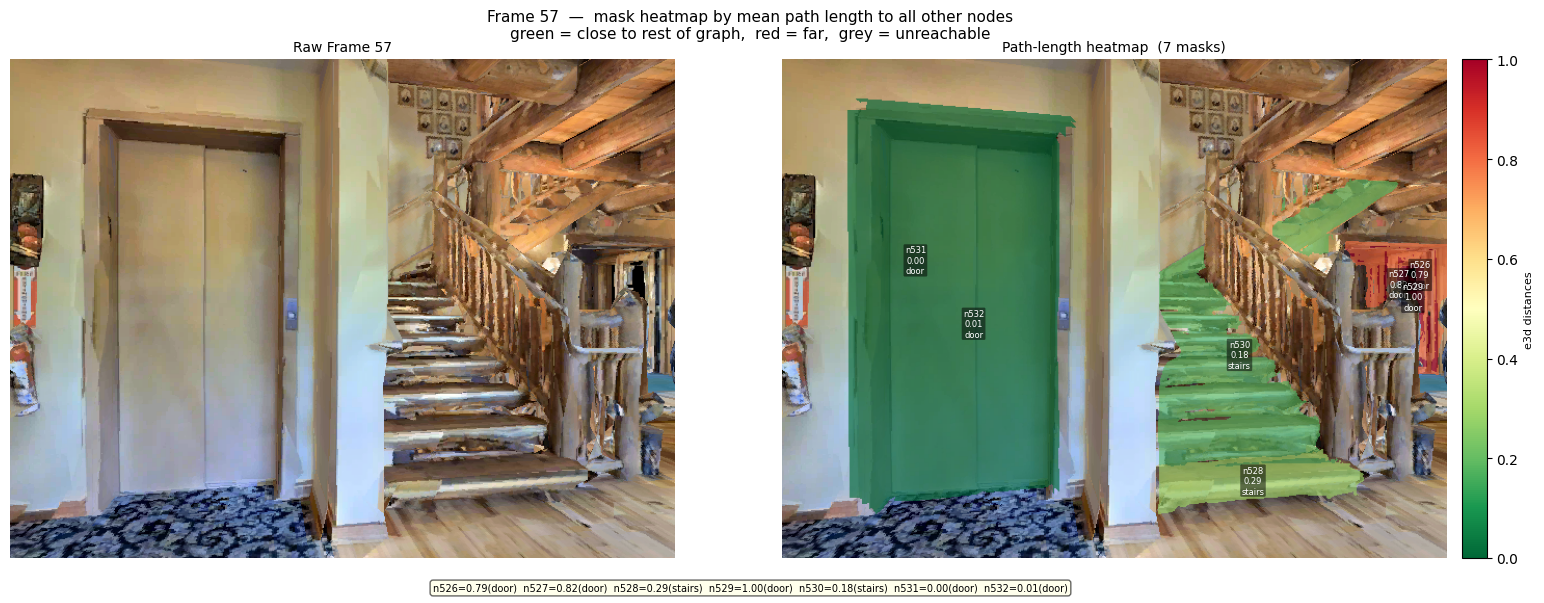

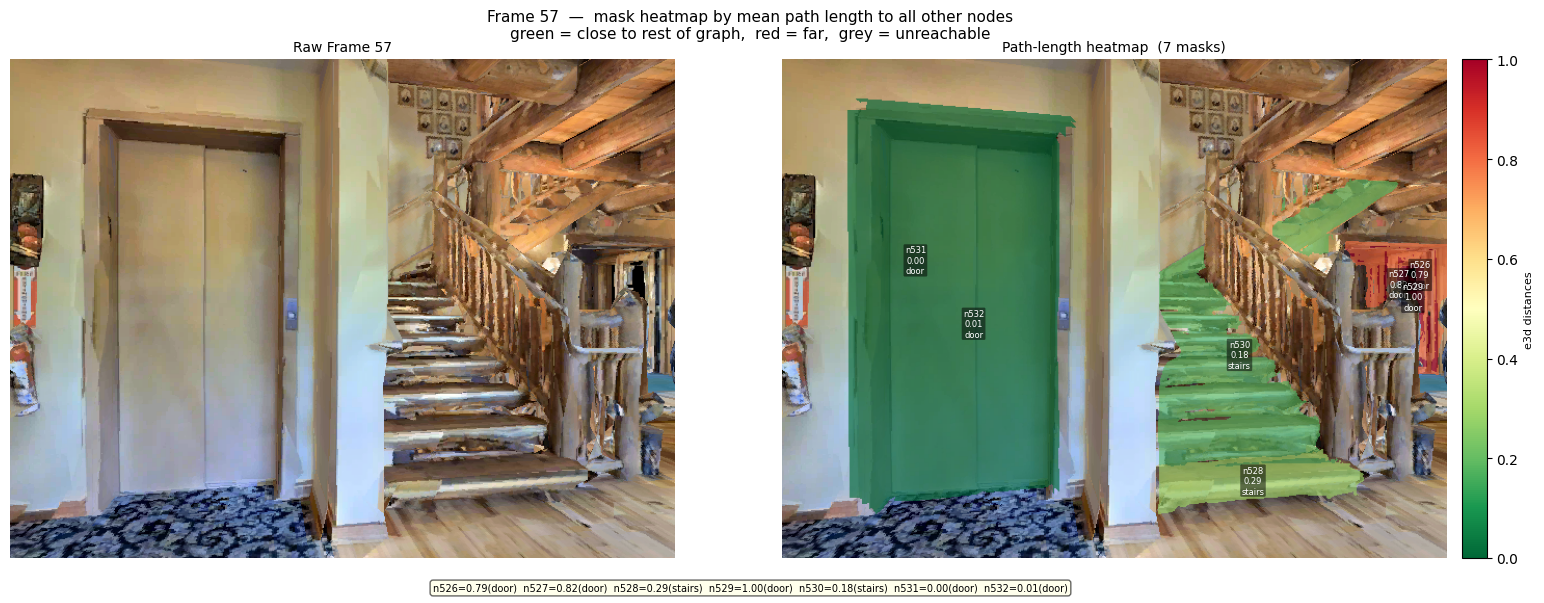

In [27]:

episode_dir = "/media/opervu-user/Data2/ws/data_langgeonet_e3d/episode_21909/"
show_frame_pathlengths_heatmap(episode_dir, query_frame_idx=57)
# show_frame_pathlengths_heatmap(episode_dir, query_frame_idx=5)

---
---

In [24]:
import sys
sys.path.insert(0, "../")
from utils.h5_writer import load_episode_from_hdf5

In [25]:
h5_path= "/media/opervu-user/Data2/ws/data_langgeonet_e3d/train.h5"

In [26]:
output= load_episode_from_hdf5(h5_path, "21909")

In [27]:
output.keys()

dict_keys(['episode_id', 'instruction', 'graph', 'frame_data'])

In [28]:
len(output["frame_data"])

94

In [34]:
G= output["graph"]


In [35]:
if "all_paths_lengths" in G.graph:
    print(G.graph['all_paths_lengths'].shape)

(1557, 1557)
